# Explainer Notebook

### Mythology vs Narrative in Warhammer 40,000 Character Network

## Table of Contents
1. [Packages and functions](#packages)
2. [Data Extraction and API](#data-extraction)
3. [Network Generation: Unfiltered and Filtered Networks](#network-generation)
4. [Data Loading and Network Construction](#data-loading)
5. [Topological Feature Extraction](#phase1)
6. [Semantic Feature Extraction](#phase2)
7. [Hybrid Analysis - The Core Discovery](#phase3)
8. [Portal vs Semantic Cluster Comparison](#phase4)
9. [Three-Way Comparison - The Complete Picture](#phase5)
10. [Research Finding: Semantic Coherence as Explanatory Mechanism](#finding)
11. [Visualizations and Interpretations](#visualizations)
12. [Conclusion](#conclusion)


<a id='packages'></a>
## 1. Import of packages and functions

In [ ]:
# Import dependencies and functions from src/
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('src')

# Import configuration
from config import DATA_PATH, PICKLE_FILTERED_FILE, PICKLE_FILE
from helpers import MAIN_PORTALS

# Import analysis functions from src/ modules
from topology import load_graph, compute_topology_metrics
from semantics import load_character_descriptions, generate_embeddings, cluster_embeddings, extract_cluster_keywords
from hybrid import calculate_neighbor_consistency, calculate_correlations
from compare_portals_clusters import get_portal_from_node, create_portal_cluster_comparison
from Analyses import load_network, calculate_modularity
from vis_utils import plot_mythology_scatter, export_results

print("All dependencies imported successfully!")
print(f"Data path: {DATA_PATH}")
print(f"Scripts available: topology.py, semantics.py, hybrid.py, compare_portals_clusters.py, Analyses.py, vis_utils.py")


All packages and functions imported successfully!
Data path: /Users/maks/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/DTU/11. semester/02805 Social graphs and interactions/Final Assignment/data
Filtered network file: /Users/maks/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/DTU/11. semester/02805 Social graphs and interactions/Final Assignment/data/lexicanum_network_filtered.pkl


<a id='data-extraction'></a>
## 2. Data Extraction and API

### Data Extraction Methodology

The data extraction was done from Warhammer 40K lexicanum wiki. We have from reliable reddit sources that this is more accurate than the fandom.wiki.
https://www.reddit.com/r/40kLore/comments/1hfyuhj/very_new_to_40k_how_canon_is_lexicanum_where/ <br>
https://www.reddit.com/r/40kLore/comments/13dqja7/lexicanum_vs_fandom/

From the lexicanum we created a list of characters and links between them by using Warhammer 40K Lexicanum API. 
https://wh40k.lexicanum.com/mediawiki/api.php

All code was written by an LLM.

### API Extraction Process

The data extraction was performed in three main steps:

1. **Initial Character Crawling** ([`api_extractor_scripts/crawler.py`](api_extractor_scripts/crawler.py))
   - Fetches character data from the Lexicanum MediaWiki API using the `query` action
   - Retrieves page extracts and links for each character
   - Implements rate limiting (0.3s sleep between requests) to be respectful to the API
   - Outputs character data to `data/raw/lexicanum_characters_by_category.json`

2. **Page Text Extraction** ([`api_extractor_scripts/extract_page_texts.py`](api_extractor_scripts/extract_page_texts.py))
   - Fetches full wikitext content for all character pages using the `revisions` API endpoint
   - Processes pages in batches to handle large datasets efficiently
   - Implements exponential backoff retry logic for robust error handling
   - Supports batching with `--start` and `--limit` parameters for processing subsets
   - Outputs batch files: `lexicanum_page_texts_batch_*.json` in the `data/processed/` directory

3. **Batch Processing** ([`api_extractor_scripts/run_batches_extract_page_texts.ps1`](api_extractor_scripts/run_batches_extract_page_texts.ps1))
   - PowerShell script to orchestrate sequential batch processing
   - Processes 12,454 total pages in batches of 1,000 pages each
   - Includes error handling and progress tracking
   - Automates the extraction of all character page texts

4. **Category Extraction** ([`api_extractor_scripts/categorize_characters.py`](api_extractor_scripts/categorize_characters.py))
   - Parses wikitext from batch files to extract MediaWiki category tags (`[[Category:...]]`)
   - Generates two output files:
     - Character-to-categories mapping: `lexicanum_character_categories.json`
     - Category-to-characters mapping: `lexicanum_characters_by_category_generated.json`
   - Used to organize characters by their wiki categories for further analysis

All scripts use the Lexicanum MediaWiki API endpoint: `https://wh40k.lexicanum.com/mediawiki/api.php`

<a id='network-generation'></a>
## 3. Network Generation: Unfiltered and Filtered Networks

### Step 1: Building the Unfiltered Network

Our network construction process (`src/create_network.py`) follows a rough 5-step pipeline:

1. **Character-to-Affiliation Mapping**
   - Maps each character to their primary affiliation (wiki portals) and all affiliations
   - _all affiliations_ which contains a mix of affiliated wars, books, factions and other affiliations. 
   - Identifies race/species separately from organizational affiliations
   - Output: `character_affiliation_mapping.json`

2. **Character Entry Creation**
   - Processes all wiki pages to identify character pages
   - Filters out non-character pages (lists, formations, categories, planets, weapons, wars)
   - Extracts faction portal templates (e.g., `{{AstraMilitarumPortal}}`) from wikitext
   - Maps extracted portals to one of 16 main faction portals, supplied by manual corrections for precision and correctness
   - Assigns portal based on affiliation if not found in wikitext
   - Output: `lexicanum_characters.json`

3. **Edge Extraction**
   - Parses the character text to find wiki link patterns, ex `[[Character Name]]` indicates a link
   - Creates directed edges from source character to target character, ex name of page (character name) is the source, and links in the character text is the targets
   - Filters out portal links, special namespaces, and self-loops
   - Handles character name variations and canonicalization by stemming and manual revision
   - Output: `lexicanum_edges.json`

4. **NetworkX Graph Construction**
   - Creates directed NetworkX graph
   - Adds attributes to notes: name, affiliation, race, portals, all_affiliations
   - Adds weighted edges (multiple links between same characters increase weight)
   - Calculates basic network statistics

5. **Graph Export**
   - Exports to GEXF format (for Gephi visualization)
   - Exports to Pickle format for analysis.
   - Output: `lexicanum_network.pkl` and `lexicanum_network.gexf`

**Statistics on the Unfiltered Network:**
- **Nodes**: ~12,401 characters
- **Edges**: ~15,978 directed edges
- **Type**: Directed graph (DiGraph)
- **Contains**: All characters from the lexicanum, this includes isolated nodes with no connections.

### Step 2: Creating the Filtered Network

The filtered network (`src/create_filtered_network.py`) is created through a filtering process:

1. **Convert to Undirected for purpose of visualization**
   - Converts the directed graph to an undirected graph
   - Combines bidirectional edges into single undirected edges
   - Preserves edge weights by summing weights of combined edges

2. **Keep Largest Connected Component**
   - Identifies all connected components in the network
   - Keeps the largest connected component
   - Removes all nodes not connected to the main network to ensure unconnected (and therefore _irrelevant_) nodes doesnt affect visualization or metrics

3. **Remove Low-Degree Nodes**
   - Iteratively removes nodes with degree < 2 to reduce amount of insignificant nodes (characters )
   - This filters out peripheral characters with very few connections and therefore little impact to the story/lore

4. **Save Filtered Network**
   - Exports filtered network to Pickle format
   - Exports to GEXF format for visualization
   - Output: `lexicanum_network_filtered.pkl` and `lexicanum_network_filtered.gexf`

**Filtered Network Statistics:**
- **Nodes**: 3,232 characters (74% reduction)
- **Edges**: 8,973 edges (44% reduction)


In [39]:
G_filtered = load_network(use_filtered=True)
print(f"Filtered network loaded: {G_filtered.number_of_nodes()} nodes, {G_filtered.number_of_edges()} edges")
print("This is the network we use for community detection")

G = load_graph(edges_file=str(DATA_PATH / 'lexicanum_edges.json'), use_filtered=True)
print(f"Directed graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("This is the network we use for betweenness, pagerank, and clustering coefficient")

Filtered network loaded: 3232 nodes, 8973 edges
This is the network we use for community detection
Directed graph loaded: 3232 nodes, 11216 edges
This is the network we use for betweenness, pagerank, and clustering coefficient


<a id='phase1'></a>
## 4. Topological Feature Extraction

### Here we calculated 4 metrics
- **Betweenness Centrality**: Identifies bridge nodes connecting different parts of the network
- **PageRank**: Measures global importance based on incoming links
- **Clustering Coefficient**: Measures local connectivity
- **Louvain Communities**: Structural grouping based on link patterns

Function: `src/topology.py: compute_topology_metrics()`

In [47]:
# Compute topology metrics using src/topology.py
print("Computing topology metrics using src/topology.compute_topology_metrics()...")

topology_df = compute_topology_metrics(G)

print(f"Topology metrics computed for {len(topology_df)} nodes")
print(f"Metrics: betweenness, pagerank, clustering_coefficient, network_community_id")
print(f"Number of communities: {topology_df['network_community_id'].nunique()}")
print("\nTop 5 by Betweenness:")
print(topology_df.nlargest(10, 'betweenness')[['node_id', 'betweenness']].to_string(index=False))


Computing topology metrics using src/topology.compute_topology_metrics()...
Topology metrics computed for 3232 nodes
Metrics: betweenness, pagerank, clustering_coefficient, network_community_id
Number of communities: 44

Top 5 by Betweenness:
           node_id  betweenness
 Roboute Guilliman     0.092981
Emperor of Mankind     0.073379
        Rogal Dorn     0.046519
            Angron     0.034744
     Cato Sicarius     0.031637
             Samus     0.030385
       Ibram Gaunt     0.027731
        Sanguinius     0.026660
         Oan Mkoll     0.025567
    Lion El'Jonson     0.023788


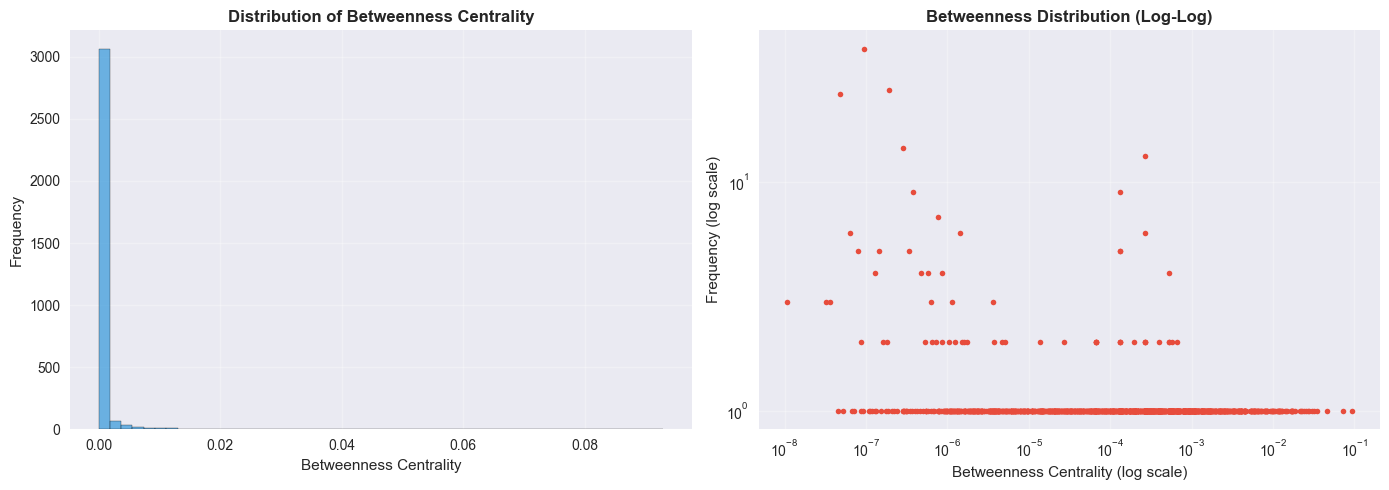

In [58]:
# Visualize betweenness distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of betweenness distribution
axes[0].hist(topology_df['betweenness'], bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_xlabel('Betweenness Centrality', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Betweenness Centrality', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Log-log plot
betweenness_values = topology_df['betweenness'].values
betweenness_values = betweenness_values[betweenness_values > 0]  # Remove zeros for log plot
unique_values, counts = np.unique(betweenness_values, return_counts=True)
axes[1].loglog(unique_values, counts, 'o', markersize=4, color='#e74c3c')
axes[1].set_xlabel('Betweenness Centrality (log scale)', fontsize=11)
axes[1].set_ylabel('Frequency (log scale)', fontsize=11)
axes[1].set_title('Betweenness Distribution (Log-Log)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/betweenness_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



<a id='phase3'></a>
## 5. Hybrid Analysis - Neighbor Semantic Consistency

For each character, we calculate the **average cosine similarity** between their text embedding and their neighbors' embeddings.

**Hypothesis**:
- **High consistency** → Narrative Agents (characters within specific story arcs)
- **Low consistency** → Mythological Anchors (characters connecting disparate parts of lore)

<a id='phase2'></a>
## 6. Semantic Feature Extraction

### Functions: `src/semantics.py`

**Purpose**: Generate semantic embeddings, cluster characters, and extract keywords.


<a id='phase3'></a>
## 7. Hybrid Analysis - The Core Discovery

### Functions: `src/hybrid.py`

**Purpose**: Calculate neighbor semantic consistency and correlations.


<a id='finding'></a>
## 10. Research Finding: Semantic Coherence as Explanatory Mechanism

**Key Finding**: Semantic coherence explains why network communities align or misalign with faction labels.


<a id='visualizations'></a>
## 11. Visualizations and Interpretations

### Functions: `src/vis_utils.py`

**Purpose**: Generate visualizations.
 

## 8. Modularity Comparison

Modularity measures how well a partition captures community structure. Higher values indicate better community structure. We compare modularity for all three partitions:
1. Network Communities (Louvain algorithm)
2. Portal Factions (official faction labels)
3. Semantic Clusters (text-based clustering)


In [28]:
# Calculate modularity using src/Analyses.py
print("Calculating modularity using src/Analyses.calculate_modularity()...")

G_undir = G_filtered if not isinstance(G_filtered, nx.DiGraph) else G_filtered.to_undirected()

node_to_community = {row['node_id']: row['network_community_id'] for _, row in df_threeway.iterrows()}
node_to_portal = {row['node_id']: row['portal'] for _, row in df_threeway.iterrows()}
node_to_cluster = {row['node_id']: int(row['semantic_cluster_id']) for _, row in df_threeway.iterrows()}

modularity_communities = calculate_modularity(G_undir, node_to_community)
modularity_portals = calculate_modularity(G_undir, node_to_portal)
modularity_clusters = calculate_modularity(G_undir, node_to_cluster)

print(f"\nModularity Comparison:")
print(f"  Network Communities: {modularity_communities:.4f}")
print(f"  Portal Factions:     {modularity_portals:.4f}")
print(f"  Semantic Clusters:   {modularity_clusters:.4f}")
print(f"\nModularity calculated using src/Analyses.py")

print("\nKey Finding:")
print("  - Network communities have the highest modularity, indicating strong structural organization")
print("  - Portal factions have moderate modularity, showing some network structure")
print("  - Semantic clusters have lower modularity, but still capture some structure")
print("  - The large difference (0.41) between communities and portals shows that")
print("    network structure encodes narrative relationships better than faction labels")


Calculating modularity using src/Analyses.calculate_modularity()...

Modularity Comparison:
  Network Communities: 0.7811
  Portal Factions:     0.3648
  Semantic Clusters:   0.3056

Modularity calculated using src/Analyses.py

Key Finding:
  - Network communities have the highest modularity, indicating strong structural organization
  - Portal factions have moderate modularity, showing some network structure
  - Semantic clusters have lower modularity, but still capture some structure
  - The large difference (0.41) between communities and portals shows that
    network structure encodes narrative relationships better than faction labels
